# TECA2 — Gerador Oficial do Dataset Sintético

Este notebook gera o dataset sintético **oficial** da atividade **TECA2 — Visão Computacional: Reconhecimento de Padrões em Cenas de Inspeção**, baseada no problema-base do Gonzalez (blobs quase elípticos em três tamanhos).

Período da atividade: **31/maio/2026 a 27/junho/2026**. O dataset oficial uniformiza os dados entre os grupos, para que diferenças acidentais de geração não contaminem a comparação entre métodos.

## O que é gerado

1. `dataset_blobs_isolados.npz` — recortes **32×32 em tons de cinza** (anti-aliased) com uma elipse simples, completa e centralizada, rotulados em A, B e C. Usado pelos classificadores de recorte (distância mínima sobre características, MLP, CNN).
2. `cenas_esteira.npz` — cenas maiores simulando uma esteira, contendo partículas completas, cortadas pela borda e sobrepostas/encostadas. Contém, por cena: a imagem em **tons de cinza** (`cenas_cinza`), uma versão **binarizada por Otsu** (`cenas_bin`), o **mapa de instâncias** (`mapas_instancia`) e o **mapa de contagem** (`mapas_contagem`). Usado na 1ª Parte: segmentação, rejeição, extração de características e classificação dos aceitos.
3. `metadados_cenas.json` / `metadados_blobs_isolados.json` — metadados geométricos por objeto (classe, centro, eixos **contínuos**, ângulo, corte por borda, sobreposição, status de referência).
4. `splits_dataset_blobs_isolados.npz` — índices oficiais de treino/validação/teste **estratificados**.
5. Imagens `.png` de inspeção visual.

## Duas decisões de projeto importantes (leia)

**(1) Por que tons de cinza com *supersampling*.** Se rasterizássemos a elipse direto no tamanho final, o comprimento de cada eixo seria um número **inteiro de pixels**. Para os eixos pequenos isso destrói a variação de ±10% (ex.: o eixo menor da classe B, em ~10 px, arredonda sempre para o mesmo valor → variância zero). Solução: desenhamos a elipse numa resolução `SS` vezes maior e reduzimos com `cv2.INTER_AREA`. A borda anti-aliased passa a codificar a posição **sub-pixel**, então o ±10% volta a ser uma variação **contínua**. A aquisição em tons de cinza também é mais realista; a binarização vira o **primeiro passo** do pipeline da 1ª Parte (e por isso é didática).

**(2) Por que o mapa de instâncias.** Numa cena, elipses sobrepostas/encostadas se fundem num único componente conexo. Sem referência, o aluno não consegue alinhar suas detecções ao *ground-truth* para montar a matriz de confusão. O `mapas_instancia` rotula cada pixel com o **id do objeto** que o ocupa (fundo = −1). Assim, um componente que cobre **mais de um** id é um *merge* (deve ser rejeitado); um componente com **um único** id mapeia para o objeto verdadeiro (classe e status conhecidos).

> O dataset oficial deve ser usado para os resultados reportados. Os metadados servem para auditoria/avaliação e **não substituem** a implementação dos módulos de segmentação, rejeição e classificação.

## 1. Dependências

No Colab, `numpy`, `opencv-python`, `matplotlib` e `scikit-learn` já costumam estar disponíveis. A célula abaixo instala apenas se necessário e roda de ponta a ponta sem intervenção.

In [1]:
# Em Colab normalmente não é preciso instalar nada.
# !pip install numpy opencv-python matplotlib scikit-learn

import os, json, zipfile
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

print("Dependências importadas com sucesso. OpenCV", cv2.__version__)

ModuleNotFoundError: No module named 'sklearn'

## 2. Parâmetros e reprodutibilidade

Classes e eixos médios do problema-base (eixos **totais**, em unidades abstratas; `SCALE` converte para pixels):

| Classe | Interpretação | Eixos médios `(a, b)` |
|---|---:|---:|
| A | grande | `(1.30, 0.70)` |
| B | média | `(1.00, 0.50)` |
| C | pequena | `(0.75, 0.25)` |

Com `SCALE = 20`, os eixos médios em px são ≈ A `(26, 14)`, B `(20, 10)`, C `(15, 5)`. A maior elipse cabe no recorte 32×32 mesmo com +10% e rotação. `SS` é o fator de *supersampling* (ver introdução).

In [2]:
SEED = 42
rng = np.random.default_rng(SEED)

SCALE    = 20      # px por unidade abstrata
IMG_SIZE = 32      # recortes isolados
VARIACAO = 0.10    # ±10% nos eixos
SS       = 8       # supersampling dos recortes isolados (256x256 -> 32x32)
SS_CENA  = 4       # supersampling das cenas (menor, por memória)

CLASSES = {
    0: {"nome": "A (grande)",  "a": 1.30, "b": 0.70},
    1: {"nome": "B (média)",   "a": 1.00, "b": 0.50},
    2: {"nome": "C (pequena)", "a": 0.75, "b": 0.25},
}

OUT_DIR = Path("dataset_teca2_oficial")
OUT_DIR.mkdir(parents=True, exist_ok=True)
print("Saída:", OUT_DIR.resolve())

Saída: /content/dataset_teca2_oficial


## 3. Funções de síntese

- `sortear_parametros_elipse`: sorteia os eixos **totais contínuos** (px) com ±10%, **sem arredondar** (a quantização é diluída pelo supersampling).
- `_draw_ss`: rasteriza uma elipse na resolução `ss`× (anti-aliased).
- `gerar_elipse_isolada`: recorte 32×32 em tons de cinza, elipse centralizada.
- `eixos_por_momentos`: estima os eixos totais a partir dos momentos centrais de 2ª ordem, ponderados por intensidade (convenção `eixo = 4√λ`). Serve de **referência** — o aluno deve reimplementar isso na 1ª Parte.
- `gerar_cena_esteira`: cena com múltiplos objetos; devolve cinza, binarizada (Otsu), mapa de instâncias e mapa de contagem.

In [3]:
def sortear_parametros_elipse(classe_id, rng):
    '''Eixos TOTAIS contínuos (px) com ±10%, sem arredondamento.'''
    p = CLASSES[int(classe_id)]
    fa = rng.uniform(1 - VARIACAO, 1 + VARIACAO)
    fb = rng.uniform(1 - VARIACAO, 1 + VARIACAO)
    eixo_a = p["a"] * SCALE * fa
    eixo_b = p["b"] * SCALE * fb
    if eixo_b > eixo_a:                       # garante maior >= menor
        eixo_a, eixo_b = eixo_b, eixo_a
        fa, fb = fb, fa
    return {"fator_a": float(fa), "fator_b": float(fb),
            "eixo_maior_px": float(eixo_a), "eixo_menor_px": float(eixo_b)}


def _draw_ss(canvas_hw, cx, cy, eixo_maior, eixo_menor, angulo, ss, valor=255):
    '''Rasteriza UMA elipse em resolução ss (uint8), anti-aliased.'''
    H, W = canvas_hw
    big = np.zeros((H * ss, W * ss), np.uint8)
    semi_a = max(1, int(round(eixo_maior / 2.0 * ss)))
    semi_b = max(1, int(round(eixo_menor / 2.0 * ss)))
    cv2.ellipse(big, (int(round(cx * ss)), int(round(cy * ss))),
                (semi_a, semi_b), float(angulo), 0, 360, valor, -1, lineType=cv2.LINE_AA)
    return big


def gerar_elipse_isolada(classe_id, rng):
    '''Recorte IMG_SIZE×IMG_SIZE em tons de cinza, elipse centralizada.'''
    geom = sortear_parametros_elipse(classe_id, rng)
    angulo = float(rng.uniform(0, 180))
    big = _draw_ss((IMG_SIZE, IMG_SIZE), IMG_SIZE / 2.0, IMG_SIZE / 2.0,
                   geom["eixo_maior_px"], geom["eixo_menor_px"], angulo, SS)
    img = cv2.resize(big, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
    meta = {"classe_id": int(classe_id), "classe_nome": CLASSES[int(classe_id)]["nome"],
            "angulo_graus": angulo, **geom}
    return img, meta


def eixos_por_momentos(img):
    '''Eixos totais por momentos centrais de 2a ordem (peso de intensidade).'''
    m = cv2.moments(img.astype(np.float64), binaryImage=False)
    if m["m00"] < 1e-9:
        return 0.0, 0.0
    mu20 = m["mu20"] / m["m00"]; mu02 = m["mu02"] / m["m00"]; mu11 = m["mu11"] / m["m00"]
    cov = np.array([[mu20, mu11], [mu11, mu02]])
    ev = np.clip(np.sort(np.linalg.eigvalsh(cov))[::-1], 0, None)
    return float(4 * np.sqrt(ev[0])), float(4 * np.sqrt(ev[1]))


def _toca_borda_ss(mask_ss):
    return bool(mask_ss[0, :].any() or mask_ss[-1, :].any() or
                mask_ss[:, 0].any() or mask_ss[:, -1].any())

def _block_reduce_max(a, ss):
    H, W = a.shape
    return a.reshape(H // ss, ss, W // ss, ss).max(axis=(1, 3))

def _block_center(a, ss):
    return a[ss // 2::ss, ss // 2::ss]


def gerar_cena_esteira(width=800, height=200, qtd=45, rng=rng):
    '''Cena de esteira. Retorna: cinza, binaria(Otsu), mapa_instancia, mapa_contagem, objetos.'''
    ss = SS_CENA
    Hs, Ws = height * ss, width * ss
    count_ss = np.zeros((Hs, Ws), np.uint8)
    inst_ss = np.full((Hs, Ws), -1, np.int32)
    objetos, mascaras = [], []

    for oid in range(qtd):
        cid = int(rng.choice([0, 1, 2]))
        geom = sortear_parametros_elipse(cid, rng)
        cx = int(rng.integers(-10, width + 10))   # centros podem cair fora -> casos de borda
        cy = int(rng.integers(-10, height + 10))
        ang = float(rng.uniform(0, 180))
        big = _draw_ss((height, width), cx, cy, geom["eixo_maior_px"], geom["eixo_menor_px"], ang, ss)
        mb = big > 127
        mascaras.append(mb)
        count_ss[mb] += 1
        inst_ss[mb] = oid                          # último desenhado vence na região de toque
        objetos.append({"id": oid, "classe_id": cid, "classe_nome": CLASSES[cid]["nome"],
                        "cx": cx, "cy": cy, "angulo_graus": ang, **geom,
                        "area_ss_px": int(mb.sum()), "cortada_borda": _toca_borda_ss(mb)})

    overlap_ss = count_ss > 1
    for i, mb in enumerate(mascaras):
        sob = bool((mb & overlap_ss).any())
        o = objetos[i]; o["sobreposta"] = sob
        if o["area_ss_px"] == 0:
            o["status_referencia"] = "fora_da_imagem"
        elif o["cortada_borda"] and sob:
            o["status_referencia"] = "rejeitar_borda_e_sobreposicao"
        elif o["cortada_borda"]:
            o["status_referencia"] = "rejeitar_borda"
        elif sob:
            o["status_referencia"] = "rejeitar_sobreposicao"
        else:
            o["status_referencia"] = "aceitar"

    uniao_ss = ((count_ss > 0).astype(np.uint8)) * 255
    cena_cinza = cv2.resize(uniao_ss, (width, height), interpolation=cv2.INTER_AREA)
    _, cena_bin = cv2.threshold(cena_cinza, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    mapa_inst = _block_center(inst_ss, ss).astype(np.int16)
    mapa_cont = _block_reduce_max(count_ss, ss).astype(np.uint8)
    objetos = [o for o in objetos if o["area_ss_px"] > 0]   # descarta totalmente fora da imagem
    return cena_cinza, cena_bin, mapa_inst, mapa_cont, objetos

print("Funções definidas.")

Funções definidas.


## 4. Dataset de blobs isolados (balanceado)

Mesma quantidade por classe. Para cada amostra guardamos os eixos **intencionais** (`eixo_maior_px`, `eixo_menor_px`) e os eixos **medidos por momentos** (`eixo_*_medido_px`), úteis para a 1ª Parte.

In [4]:
QTD_POR_CLASSE = 2000

X, y, metadados_blobs = [], [], []
for cid in sorted(CLASSES):
    for _ in range(QTD_POR_CLASSE):
        img, meta = gerar_elipse_isolada(cid, rng)
        em, en = eixos_por_momentos(img)
        meta["eixo_maior_medido_px"] = em
        meta["eixo_menor_medido_px"] = en
        meta["amostra_id"] = len(X)
        X.append(img); y.append(cid); metadados_blobs.append(meta)

X = np.asarray(X, np.uint8)
y = np.asarray(y, np.int64)

idx = np.arange(len(X)); rng.shuffle(idx)          # embaralhamento reprodutível
X, y = X[idx], y[idx]
metadados_blobs = [metadados_blobs[int(i)] for i in idx]

np.savez_compressed(OUT_DIR / "dataset_blobs_isolados.npz", X=X, y=y,
    class_names=np.array([CLASSES[i]["nome"] for i in sorted(CLASSES)]),
    scale=np.array(SCALE), seed=np.array(SEED), img_size=np.array(IMG_SIZE),
    variacao=np.array(VARIACAO), supersampling=np.array(SS))
with open(OUT_DIR / "metadados_blobs_isolados.json", "w", encoding="utf-8") as f:
    json.dump(metadados_blobs, f, ensure_ascii=False, indent=2)

print("X:", X.shape, X.dtype, "| níveis de cinza:", len(np.unique(X)))
print("distribuição:", dict(zip(*np.unique(y, return_counts=True))))

X: (6000, 32, 32) uint8 | níveis de cinza: 256
distribuição: {np.int64(0): np.int64(2000), np.int64(1): np.int64(2000), np.int64(2): np.int64(2000)}


## 5. Splits oficiais estratificados (70 / 15 / 15)

Use estes índices na 2ª Parte para comparar os grupos de forma justa. Na 1ª Parte, use o treino para estimar os protótipos da distância mínima e o teste para avaliar.

In [5]:
all_indices = np.arange(len(y))
idx_train, idx_temp, y_train, y_temp = train_test_split(
    all_indices, y, test_size=0.30, random_state=SEED, stratify=y)
idx_val, idx_test, y_val, y_test = train_test_split(
    idx_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp)

np.savez_compressed(OUT_DIR / "splits_dataset_blobs_isolados.npz",
    idx_train=idx_train, idx_val=idx_val, idx_test=idx_test, seed=np.array(SEED))

print("treino/val/teste:", len(idx_train), len(idx_val), len(idx_test))
for nome, ix in [("treino", idx_train), ("val", idx_val), ("teste", idx_test)]:
    v, c = np.unique(y[ix], return_counts=True); print(" ", nome, dict(zip(v, c)))

treino/val/teste: 4200 900 900
  treino {np.int64(0): np.int64(1400), np.int64(1): np.int64(1400), np.int64(2): np.int64(1400)}
  val {np.int64(0): np.int64(300), np.int64(1): np.int64(300), np.int64(2): np.int64(300)}
  teste {np.int64(0): np.int64(300), np.int64(1): np.int64(300), np.int64(2): np.int64(300)}


## 6. Verificação: o ±10% voltou a ser contínuo

Aqui está o motivo do supersampling. Olhamos o **eixo menor medido** por classe: com a rasterização ingênua ele colapsava (a classe B ficava com **um único valor**). Agora cada classe é uma nuvem contínua. As três continuam **separáveis** — é exatamente a premissa da atividade (se já é separável, a CNN se justifica?), mas com variação real para discutir margem e robustez.

Eixo MENOR medido (px) por classe:
  A (grande): min=12.70 med=14.20 max=15.71 std=0.815
  B (média): min=9.22 med=10.22 max=11.25 std=0.577
  C (pequena): min=4.77 med=5.29 max=5.81 std=0.296


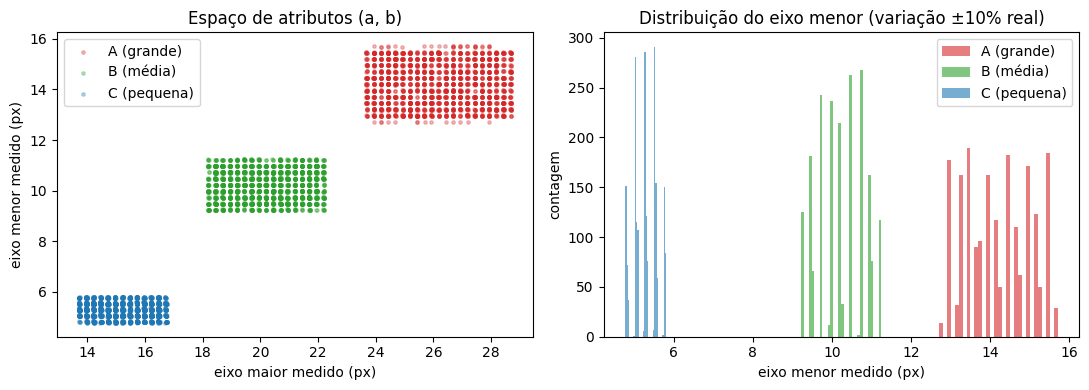

In [6]:
maior = np.array([m["eixo_maior_medido_px"] for m in metadados_blobs])
menor = np.array([m["eixo_menor_medido_px"] for m in metadados_blobs])
cls   = np.array([m["classe_id"] for m in metadados_blobs])

print("Eixo MENOR medido (px) por classe:")
for c in [0, 1, 2]:
    v = menor[cls == c]
    print(f"  {CLASSES[c]['nome']}: min={v.min():.2f} med={np.median(v):.2f} "
          f"max={v.max():.2f} std={v.std():.3f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
cores = {0: "tab:red", 1: "tab:green", 2: "tab:blue"}
for c in [0, 1, 2]:
    ax[0].scatter(maior[cls == c], menor[cls == c], s=6, alpha=0.3,
                  color=cores[c], label=CLASSES[c]["nome"])
ax[0].set_xlabel("eixo maior medido (px)"); ax[0].set_ylabel("eixo menor medido (px)")
ax[0].set_title("Espaço de atributos (a, b)"); ax[0].legend()
for c in [0, 1, 2]:
    ax[1].hist(menor[cls == c], bins=30, alpha=0.6, color=cores[c], label=CLASSES[c]["nome"])
ax[1].set_xlabel("eixo menor medido (px)"); ax[1].set_ylabel("contagem")
ax[1].set_title("Distribuição do eixo menor (variação ±10% real)"); ax[1].legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "verificacao_eixos.png", dpi=200, bbox_inches="tight")
plt.show()

## 7. Visualização de recortes isolados

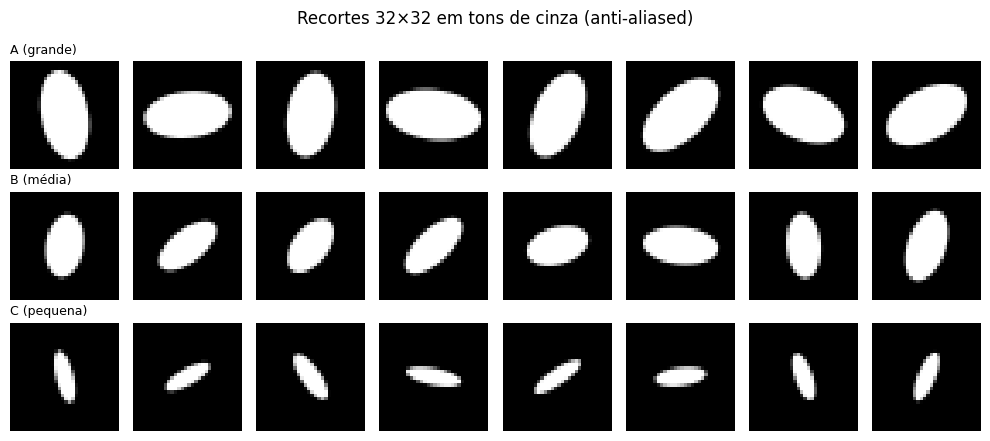

In [7]:
fig, axes = plt.subplots(3, 8, figsize=(10, 4.5))
for cid in sorted(CLASSES):
    idxs = np.where(y == cid)[0][:8]
    for j, ix in enumerate(idxs):
        ax = axes[cid, j]
        ax.imshow(X[ix], cmap="gray", vmin=0, vmax=255); ax.axis("off")
    axes[cid, 0].set_title(CLASSES[cid]["nome"], fontsize=9, loc="left")
plt.suptitle("Recortes 32×32 em tons de cinza (anti-aliased)")
plt.tight_layout()
plt.savefig(OUT_DIR / "amostras_blobs_isolados.png", dpi=200, bbox_inches="tight")
plt.show()

## 8. Cenas de esteira

Múltiplos objetos no mesmo campo: completos, cortados pela borda e sobrepostos/encostados. Cada cena devolve a imagem em cinza, a binarização por Otsu, o mapa de instâncias e o de contagem. Os metadados trazem o **status de referência** por objeto.

In [8]:
QTD_CENAS, WIDTH, HEIGHT, QTD_PARTICULAS = 10, 800, 200, 45

cenas_cinza, cenas_bin, mapas_inst, mapas_cont, metadados_cenas = [], [], [], [], []
for cena_id in range(QTD_CENAS):
    cg, cb, mi, mc, objs = gerar_cena_esteira(WIDTH, HEIGHT, QTD_PARTICULAS, rng=rng)
    cenas_cinza.append(cg); cenas_bin.append(cb)
    mapas_inst.append(mi); mapas_cont.append(mc)
    metadados_cenas.append({"cena_id": cena_id, "width": WIDTH, "height": HEIGHT,
                            "qtd_particulas_sorteadas": QTD_PARTICULAS, "objetos": objs})

cenas_cinza = np.asarray(cenas_cinza, np.uint8)
cenas_bin   = np.asarray(cenas_bin, np.uint8)
mapas_inst  = np.asarray(mapas_inst, np.int16)
mapas_cont  = np.asarray(mapas_cont, np.uint8)

np.savez_compressed(OUT_DIR / "cenas_esteira.npz",
    cenas_cinza=cenas_cinza, cenas_bin=cenas_bin,
    mapas_instancia=mapas_inst, mapas_contagem=mapas_cont,
    scale=np.array(SCALE), seed=np.array(SEED),
    width=np.array(WIDTH), height=np.array(HEIGHT),
    qtd_particulas_por_cena=np.array(QTD_PARTICULAS))
with open(OUT_DIR / "metadados_cenas.json", "w", encoding="utf-8") as f:
    json.dump(metadados_cenas, f, ensure_ascii=False, indent=2)

print("cenas_cinza:", cenas_cinza.shape, "| cenas_bin:", cenas_bin.shape,
      "| mapas_instancia:", mapas_inst.shape, "| mapas_contagem:", mapas_cont.shape)

cenas_cinza: (10, 200, 800) | cenas_bin: (10, 200, 800) | mapas_instancia: (10, 200, 800) | mapas_contagem: (10, 200, 800)


## 9. Resumo das cenas e checagem de alinhamento

Mostramos a distribuição dos status de referência e comparamos o nº de **componentes conexas** (binária) com o nº de **objetos visíveis**. Eles diferem porque sobreposições/toques fundem objetos — e é por isso que o mapa de instâncias existe.

In [9]:
status = {}
for cm in metadados_cenas:
    for o in cm["objetos"]:
        status[o["status_referencia"]] = status.get(o["status_referencia"], 0) + 1
print("Status de referência (todas as cenas):")
for k in sorted(status): print(f"  {k}: {status[k]}")

print("\nComponentes conexas (binária) × objetos visíveis:")
for i in range(min(5, len(cenas_bin))):
    n, _ = cv2.connectedComponents(cenas_bin[i])
    print(f"  cena {i}: componentes={n-1:3d} | objetos_visíveis={len(metadados_cenas[i]['objetos']):3d}")

Status de referência (todas as cenas):
  aceitar: 302
  rejeitar_borda: 62
  rejeitar_borda_e_sobreposicao: 18
  rejeitar_sobreposicao: 52

Componentes conexas (binária) × objetos visíveis:
  cena 0: componentes= 38 | objetos_visíveis= 43
  cena 1: componentes= 36 | objetos_visíveis= 44
  cena 2: componentes= 42 | objetos_visíveis= 45
  cena 3: componentes= 40 | objetos_visíveis= 44
  cena 4: componentes= 40 | objetos_visíveis= 44


## 10. Visualização das cenas

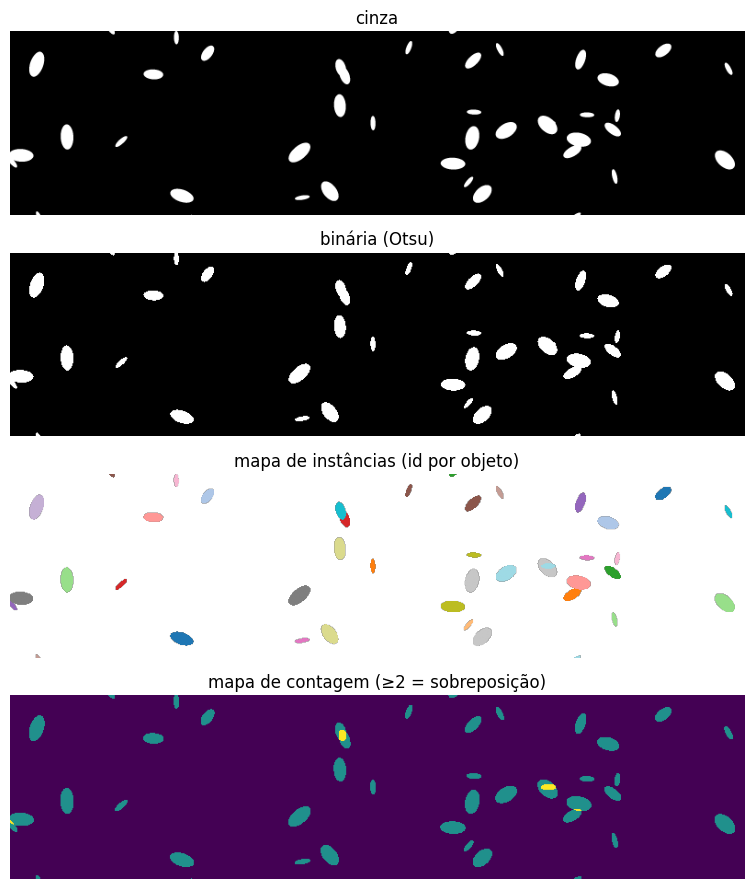

In [10]:
i = 0
fig, ax = plt.subplots(4, 1, figsize=(12, 9))
ax[0].imshow(cenas_cinza[i], cmap="gray", vmin=0, vmax=255); ax[0].set_title("cinza"); ax[0].axis("off")
ax[1].imshow(cenas_bin[i], cmap="gray", vmin=0, vmax=255); ax[1].set_title("binária (Otsu)"); ax[1].axis("off")
inst_show = np.where(mapas_inst[i] < 0, np.nan, mapas_inst[i])
ax[2].imshow(inst_show, cmap="tab20"); ax[2].set_title("mapa de instâncias (id por objeto)"); ax[2].axis("off")
ax[3].imshow(mapas_cont[i], cmap="viridis"); ax[3].set_title("mapa de contagem (≥2 = sobreposição)"); ax[3].axis("off")
plt.tight_layout()
plt.savefig(OUT_DIR / "exemplo_cena_camadas.png", dpi=200, bbox_inches="tight")
plt.show()

## 11. Como carregar e como usar o mapa de instâncias

A célula abaixo carrega os arquivos e mostra o **padrão de avaliação** da 1ª Parte: para cada componente conexa detectada, consultamos os ids no mapa de instâncias. Componente com **um id** → objeto verdadeiro (classe/status conhecidos); componente com **vários ids** → *merge* (rejeitar). É assim que se monta a matriz de confusão "3 classes + rejeitado".

In [11]:
dados = np.load(OUT_DIR / "dataset_blobs_isolados.npz", allow_pickle=True)
splits = np.load(OUT_DIR / "splits_dataset_blobs_isolados.npz")
dc = np.load(OUT_DIR / "cenas_esteira.npz", allow_pickle=True)
with open(OUT_DIR / "metadados_cenas.json", encoding="utf-8") as f:
    meta_cenas = json.load(f)

print("blobs:", dados["X"].shape, "| treino/val/teste:",
      len(splits["idx_train"]), len(splits["idx_val"]), len(splits["idx_test"]))

# Exemplo de alinhamento componente -> ground-truth na cena 0
i = 0
binimg = dc["cenas_bin"][i]; inst = dc["mapas_instancia"][i]
gt = {o["id"]: o for o in meta_cenas[i]["objetos"]}
n, lab = cv2.connectedComponents(binimg)
puros, merges = 0, 0
for k in range(1, n):
    ids = set(np.unique(inst[lab == k])) - {-1}
    if len(ids) == 1:
        puros += 1
        # obj = gt[ids.pop()]  ->  obj["classe_nome"], obj["status_referencia"]
    elif len(ids) > 1:
        merges += 1
print(f"cena {i}: {n-1} componentes -> {puros} mapeiam p/ 1 objeto, {merges} são merges (rejeitar)")

blobs: (6000, 32, 32) | treino/val/teste: 4200 900 900
cena 0: 38 componentes -> 34 mapeiam p/ 1 objeto, 4 são merges (rejeitar)


## 12. Compactação para distribuição

In [12]:
zip_path = Path("dataset_teca2_oficial.zip")
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for fp in OUT_DIR.rglob("*"):
        if fp.is_file():
            zf.write(fp, arcname=fp.relative_to(OUT_DIR.parent))
print("ZIP:", zip_path.resolve(), f"({zip_path.stat().st_size/1e6:.2f} MB)")

ZIP: /content/dataset_teca2_oficial.zip (1.78 MB)


## 13. Registro das decisões de projeto

- Seed: `42`. Escala: `20 px/unidade`. Recortes: `32×32` em **tons de cinza**.
- Variação dos eixos: uniforme em **±10%**, contínua (sem arredondamento), preservada por **supersampling** (`SS=8` nos recortes, `SS_CENA=4` nas cenas) + redução `INTER_AREA`.
- Classes A `(1.30, 0.70)`, B `(1.00, 0.50)`, C `(0.75, 0.25)`.
- Eixos estimados por momentos de 2ª ordem (`eixo = 4√λ`), ponderados por intensidade.
- Cenas `800×200`, `45` partículas; centros podem cair fora da imagem (casos de borda); sobreposição por mapa de contagem.
- Cada cena: cinza + binária (Otsu) + **mapa de instâncias** (id por pixel, fundo −1) + mapa de contagem.
- Splits estratificados `70/15/15`.

Cite estas escolhas ao documentar os experimentos. Para reprodutibilidade, rode o notebook **de cima para baixo uma vez**.